# Model Fine-tuning


This notebook performs fine-tuning of the MentalRoBERTa and BERT-base models on the processed mental health datasets.

## Importing Libraries and Utilities

In [1]:
# Import system libraries and set up path for utility modules
import sys
import os

# Add the "src" directory to sys.path to import pipeline utility functions
sys.path.append(os.path.abspath(os.path.join(os.pardir, "src")))

In [2]:
# Import main libraries for data handling, training, visualization, and system utilities
import gc
import os
import pickle

import matplotlib.pyplot as plt
import torch

In [3]:
# Import the main training pipeline function
from train import train_model

In [4]:
# Utility function to save training history for all models/datasets as a pickle file
def save_history_all(history_dict, filename="history_all.pkl"):
    """Save the training history dictionary to a pickle file."""
    with open(filename, "wb") as f:
        pickle.dump(history_dict, f)
    print(f"History saved to {filename}")

In [5]:
# Utility function to load saved training history, if it exists
def load_history_all(filename="history_all.pkl"):
    """Load the training history dictionary from a pickle file, if it exists."""
    if os.path.exists(filename):
        with open(filename, "rb") as f:
            return pickle.load(f)
    return {}

## Parameter Configuration

In [6]:
MODELS = [
    "google-bert/bert-base-uncased",
    "mental/mental-roberta-base",
]

DATASETS = [
    "suicide-and-depression-detection",
    "sentiment-analysis-for-mental-health",
    "sentimental-analysis-for-tweets",
    "mental-health-corpus"
]

print("Models:", MODELS)
print("Datasets:", DATASETS)

Models: ['google-bert/bert-base-uncased', 'mental/mental-roberta-base']
Datasets: ['suicide-and-depression-detection', 'sentiment-analysis-for-mental-health', 'sentimental-analysis-for-tweets', 'mental-health-corpus']


In [7]:
BATCH_SIZE = 16           # Training batch size
EPOCHS = 3                # Number of training epochs
LEARNING_RATE = 2e-5      # Optimizer learning rate
MAX_LENGTH = 256          # Maximum token sequence length
SEED = 42                 # Seed for reproducibility

In [8]:
# Load saved training history if available
HISTORY_ALL = load_history_all("history_all.pkl")

## Model Training

### Suicide and Depression Detection Dataset

In [9]:
# Train BERT-base ("google-bert/bert-base-uncased") on the "suicide-and-depression-detection" dataset
model_name = "google-bert/bert-base-uncased"
dataset = "suicide-and-depression-detection"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training google-bert/bert-base-uncased on dataset suicide-and-depression-detection =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [1:24:03<2:48:07, 5043.78s/it]

Train acc: 0.9582 | loss: 0.1084 | Val acc: 0.9755 | loss: 0.0764
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [2:46:17<1:22:58, 4978.95s/it]

Train acc: 0.9856 | loss: 0.0414 | Val acc: 0.9781 | loss: 0.0601
Epoch 3/3


Epochs: 100%|██████████| 3/3 [4:07:55<00:00, 4958.41s/it]  

Train acc: 0.9956 | loss: 0.0138 | Val acc: 0.9789 | loss: 0.0773


Model google-bert/bert-base-uncased trained and saved for dataset suicide-and-depression-detection.


In [10]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [11]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

In [12]:
# Train MentalRoBERTa ("mental/mental-roberta-base") on the "suicide-and-depression-detection" dataset
model_name = "mental/mental-roberta-base"
dataset = "suicide-and-depression-detection"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training mental/mental-roberta-base on dataset suicide-and-depression-detection =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [1:17:44<2:35:29, 4664.85s/it]

Train acc: 0.9745 | loss: 0.0634 | Val acc: 0.9911 | loss: 0.0279
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [2:34:34<1:17:12, 4632.36s/it]

Train acc: 0.9934 | loss: 0.0192 | Val acc: 0.9916 | loss: 0.0261
Epoch 3/3


Epochs: 100%|██████████| 3/3 [3:56:09<00:00, 4723.13s/it]  

Train acc: 0.9979 | loss: 0.0067 | Val acc: 0.9921 | loss: 0.0283


Model mental/mental-roberta-base trained and saved for dataset suicide-and-depression-detection.


In [13]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [14]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

### Sentiment Analysis for Mental Health Dataset

In [15]:
# Train BERT-base ("google-bert/bert-base-uncased") on the "sentiment-analysis-for-mental-health" dataset
model_name = "google-bert/bert-base-uncased"
dataset = "sentiment-analysis-for-mental-health"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training google-bert/bert-base-uncased on dataset sentiment-analysis-for-mental-health =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [16:26<32:52, 986.26s/it]

Train acc: 0.7357 | loss: 0.6860 | Val acc: 0.8205 | loss: 0.4513
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [32:51<16:25, 985.58s/it]

Train acc: 0.8585 | loss: 0.3531 | Val acc: 0.8356 | loss: 0.4106
Epoch 3/3


Epochs: 100%|██████████| 3/3 [49:59<00:00, 999.82s/it] 

Train acc: 0.9039 | loss: 0.2425 | Val acc: 0.8334 | loss: 0.4258


Model google-bert/bert-base-uncased trained and saved for dataset sentiment-analysis-for-mental-health.


In [16]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [17]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

In [18]:
# Train MentalRoBERTa ("mental/mental-roberta-base") on the "sentiment-analysis-for-mental-health" dataset
model_name = "mental/mental-roberta-base"
dataset = "sentiment-analysis-for-mental-health"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training mental/mental-roberta-base on dataset sentiment-analysis-for-mental-health =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [18:09<36:18, 1089.49s/it]

Train acc: 0.7570 | loss: 0.6154 | Val acc: 0.8258 | loss: 0.4280
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [36:17<18:08, 1088.39s/it]

Train acc: 0.8579 | loss: 0.3469 | Val acc: 0.8359 | loss: 0.4035
Epoch 3/3


Epochs: 100%|██████████| 3/3 [53:22<00:00, 1067.36s/it]

Train acc: 0.8948 | loss: 0.2598 | Val acc: 0.8375 | loss: 0.4011


Model mental/mental-roberta-base trained and saved for dataset sentiment-analysis-for-mental-health.


In [19]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [20]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

### Sentimental Analysis for Tweets Dataset

In [21]:
# Train BERT-base ("google-bert/bert-base-uncased") on the "sentimental-analysis-for-tweets" dataset
model_name = "google-bert/bert-base-uncased"
dataset = "sentimental-analysis-for-tweets"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training google-bert/bert-base-uncased on dataset sentimental-analysis-for-tweets =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [01:24<02:49, 84.68s/it]

Train acc: 0.9179 | loss: 0.1977 | Val acc: 0.9841 | loss: 0.0498
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [02:49<01:24, 84.61s/it]

Train acc: 0.9966 | loss: 0.0172 | Val acc: 0.9887 | loss: 0.0584
Epoch 3/3


Epochs: 100%|██████████| 3/3 [04:13<00:00, 84.57s/it]

Train acc: 0.9989 | loss: 0.0066 | Val acc: 0.9864 | loss: 0.0634


Model google-bert/bert-base-uncased trained and saved for dataset sentimental-analysis-for-tweets.


In [22]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [23]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

In [24]:
# Train MentalRoBERTa ("mental/mental-roberta-base") on the "sentimental-analysis-for-tweets" dataset
model_name = "mental/mental-roberta-base"
dataset = "sentimental-analysis-for-tweets"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training mental/mental-roberta-base on dataset sentimental-analysis-for-tweets =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [01:25<02:51, 85.85s/it]

Train acc: 0.8961 | loss: 0.2127 | Val acc: 0.9932 | loss: 0.0427
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [02:51<01:25, 85.92s/it]

Train acc: 0.9938 | loss: 0.0231 | Val acc: 0.9887 | loss: 0.0501
Epoch 3/3


Epochs: 100%|██████████| 3/3 [04:17<00:00, 85.80s/it]

Train acc: 0.9977 | loss: 0.0081 | Val acc: 0.9887 | loss: 0.0616


Model mental/mental-roberta-base trained and saved for dataset sentimental-analysis-for-tweets.


In [25]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [26]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

### Mental Health Corpus Dataset

In [27]:
# Train BERT-base ("google-bert/bert-base-uncased") on the "mental-health-corpus" dataset
model_name = "google-bert/bert-base-uncased"
dataset = "mental-health-corpus"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training google-bert/bert-base-uncased on dataset mental-health-corpus =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [08:49<17:38, 529.29s/it]

Train acc: 0.9138 | loss: 0.2026 | Val acc: 0.9647 | loss: 0.1032
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [17:40<08:50, 530.39s/it]

Train acc: 0.9755 | loss: 0.0669 | Val acc: 0.9665 | loss: 0.1057
Epoch 3/3


Epochs: 100%|██████████| 3/3 [27:04<00:00, 541.62s/it]

Train acc: 0.9909 | loss: 0.0262 | Val acc: 0.9655 | loss: 0.1174


Model google-bert/bert-base-uncased trained and saved for dataset mental-health-corpus.


In [28]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [29]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

In [30]:
# Train MentalRoBERTa ("mental/mental-roberta-base") on the "mental-health-corpus" dataset
model_name = "mental/mental-roberta-base"
dataset = "mental-health-corpus"
print(f"\n===== Training {model_name} on dataset {dataset} =====")

data_dir = f"../data/processed/{dataset}"
output_dir = f"../models/{dataset}"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, tokenizer, train_loader, val_loader, test_loader, label2id, id2label, history = train_model(
    model_name=model_name,
    data_dir=data_dir,
    output_dir=output_dir,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    max_length=MAX_LENGTH,
    seed=SEED,
    device=device,
    return_history=True,
)

HISTORY_ALL[(model_name, dataset)] = history
print(f"Model {model_name} trained and saved for dataset {dataset}.")


===== Training mental/mental-roberta-base on dataset mental-health-corpus =====


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3


Epochs:  33%|███▎      | 1/3 [09:36<19:13, 576.85s/it]

Train acc: 0.9213 | loss: 0.1893 | Val acc: 0.9665 | loss: 0.0899
Epoch 2/3


Epochs:  67%|██████▋   | 2/3 [19:15<09:37, 577.99s/it]

Train acc: 0.9747 | loss: 0.0697 | Val acc: 0.9727 | loss: 0.0793
Epoch 3/3


Epochs: 100%|██████████| 3/3 [28:58<00:00, 579.36s/it]

Train acc: 0.9907 | loss: 0.0286 | Val acc: 0.9702 | loss: 0.0974


Model mental/mental-roberta-base trained and saved for dataset mental-health-corpus.


In [31]:
# Save intermediate history after training this model
save_history_all(HISTORY_ALL, filename="history_all.pkl")

History saved to history_all.pkl


In [32]:
# Clear memory after training this model
torch.cuda.empty_cache()
gc.collect();

## Training History Visualization

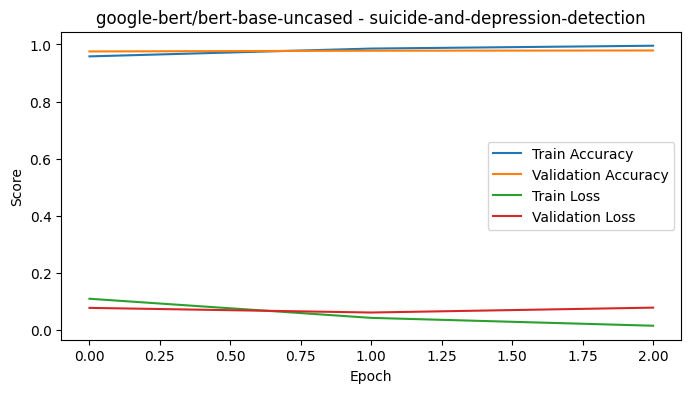

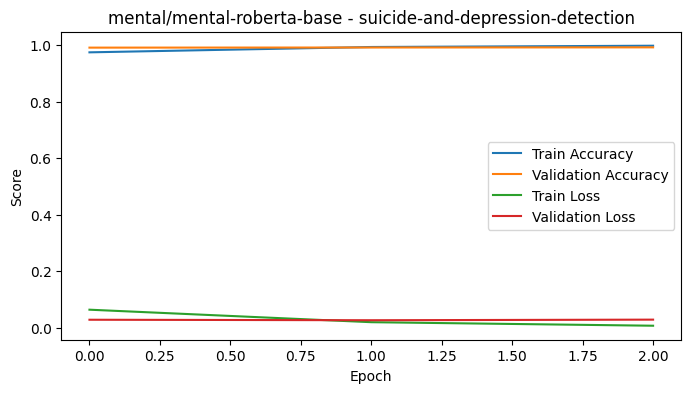

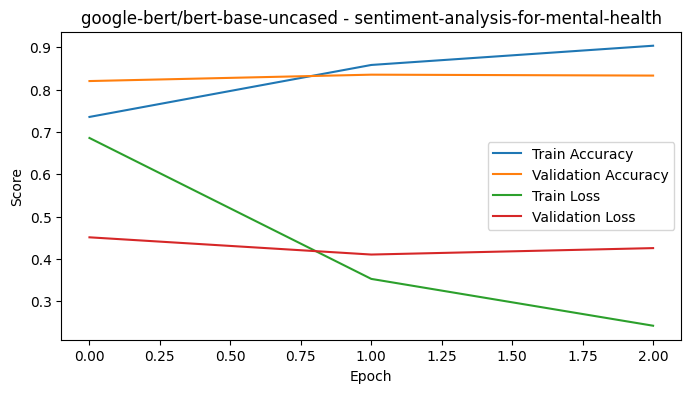

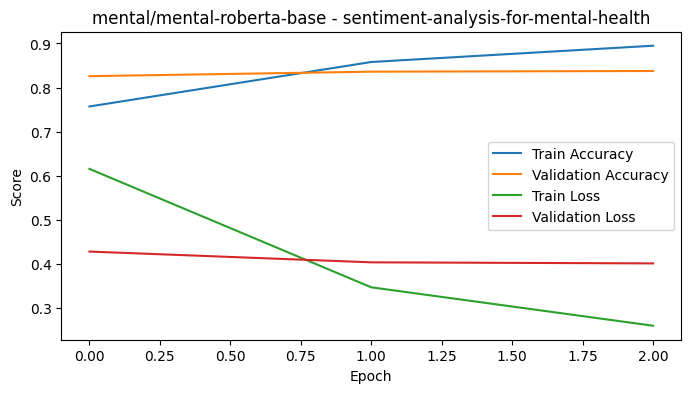

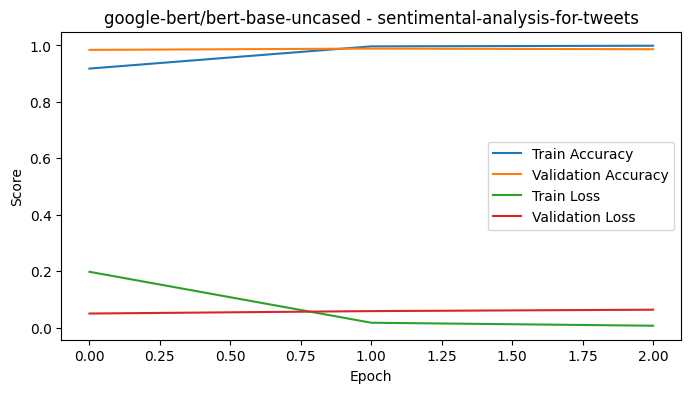

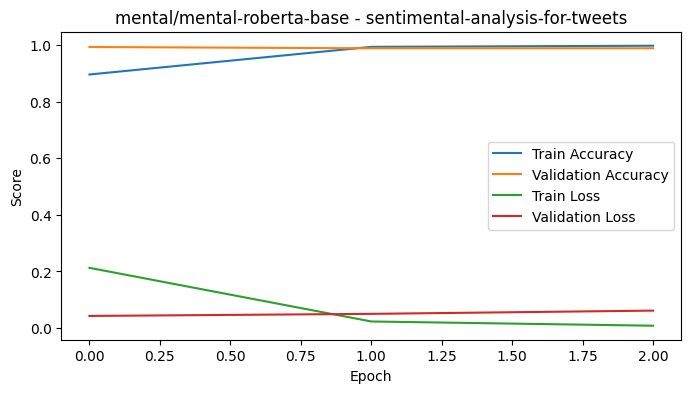

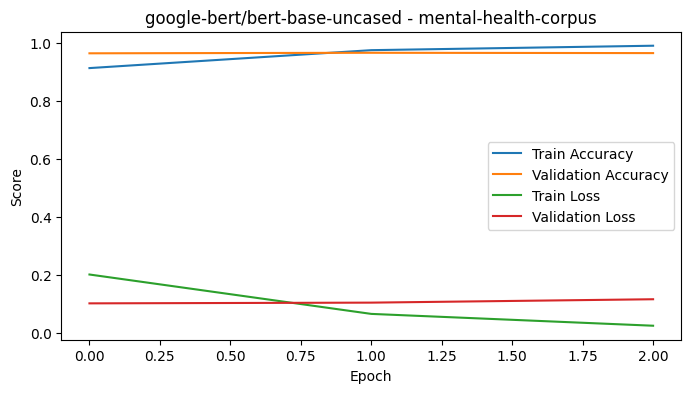

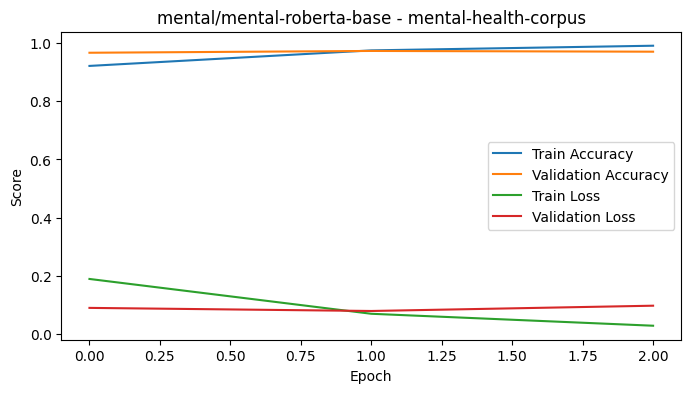

In [33]:
# Visualize training history for all models and datasets
for (model_name, dataset), hist in HISTORY_ALL.items():
    plt.figure(figsize=(8,4))
    plt.plot(hist["train_acc"], label="Train Accuracy")
    plt.plot(hist["val_acc"], label="Validation Accuracy")
    plt.plot(hist["train_loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - {dataset}")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

## Final Remarks


- Fine-tuning was performed for all models and processed datasets, using a modular pipeline and training history visualization.
- Models and tokenizers were saved in directories organized by dataset and architecture.